In [1]:
import os
os.chdir(r"C:\Users\Annie.LAPTOP-NJ5KV9M1\AGN_mapping")

In [2]:
pip install astropy scipy matplotlib numpy h5py tqdm numba pint-pulsar emcee corner statsmodels pyfftw tbb

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install pytest pytest-astropy jinja2 docutils sphinx-astropy nbsphinx pandoc ipython jupyter notebook towncrier tox black

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install stingray PyROA emcee tabulate corner astropy

Note: you may need to restart the kernel to use updated packages.


In [5]:
import shutil

# Replace '/path/to/work_directory' with your actual work directory

src = r'C:\Users\Annie.LAPTOP-NJ5KV9M1\AGN_mapping\CPython\PYCCF.py'
dst = r'PYCCF.py'
dst2 = r'xcorspc.pyx'

shutil.copy(src, dst)
shutil.copy(src, dst2)

'xcorspc.pyx'

In [6]:
import os
print(os.getcwd())

C:\Users\Annie.LAPTOP-NJ5KV9M1\AGN_mapping


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import argparse
import random

from scipy import stats
import scipy.integrate as integrate

from stingray import Lightcurve, Crossspectrum, AveragedCrossspectrum

import PYCCF as myccf
import PyROA
import psi

import importlib
importlib.reload(psi)


<module 'psi' from 'C:\\Users\\Annie.LAPTOP-NJ5KV9M1\\AGN_mapping\\psi.py'>

In [8]:
import scipy
print(scipy.__version__)
print(scipy.__file__)

1.15.2
c:\Users\Annie.LAPTOP-NJ5KV9M1\miniconda3\envs\agn\lib\site-packages\scipy\__init__.py


In [9]:
#import AGN light curve
directory_path = r'C:\Users\Annie.LAPTOP-NJ5KV9M1\AGN_mapping\data'
file_path = os.path.join(directory_path, 'lc30mins.dat')

column_index1 = 0  
column_index2 = 1

with open(file_path, 'r') as file:
    # Read all lines
    lines = file.readlines()
    data_lines = lines[1:]
    
   # Extract the desired columns from each line and convert to float
    column1_data = [float(line.split()[column_index1]) for line in data_lines]
    column2_data = [float(line.split()[column_index2]) for line in data_lines]

time = np.array(column1_data)/(24*3600)
flux = np.array(column2_data)

dt = 1800 #each interval in seconds 

exposure = len(time) #length of full array 
seconds_day = 86400
original_length = exposure/(seconds_day/dt)

#times = (np.linspace(-exposure, exposure+1, num = exposure*2)*dt)/(24*3600) # converted to days
times = (np.linspace(1, exposure+1, num = exposure)*dt)/(24*3600)

#define disk function
def disk(times,wavelength):
    bhmass = 10**7.7       # Msol
    mdot = 0.5         # Msol/yr
    inc = 45           # inclination, degrees
    combi_psi = psi.pytfb_sub(times,1e8,mdot,wavelength,inc,norm=1)
    combi_psi[np.isnan(combi_psi)]=0
    # normalise 
    normi = np.trapz(combi_psi,x=times)
    return (combi_psi/normi)


combi_psi_1 = disk(times, 4770)


## below checking the disk response function to see if it is normalised


In [10]:
# integrate disk response function

normalisation = np.trapz(combi_psi_1, times)
mean_lag = np.trapz(times * combi_psi_1, x=times)

print("Integral =", normalisation)
print("Mean lag =", mean_lag)

Integral = 0.9999999999999999
Mean lag = 2.046092179520479


In [11]:
psi_norm = combi_psi_1 / np.sum(combi_psi_1)

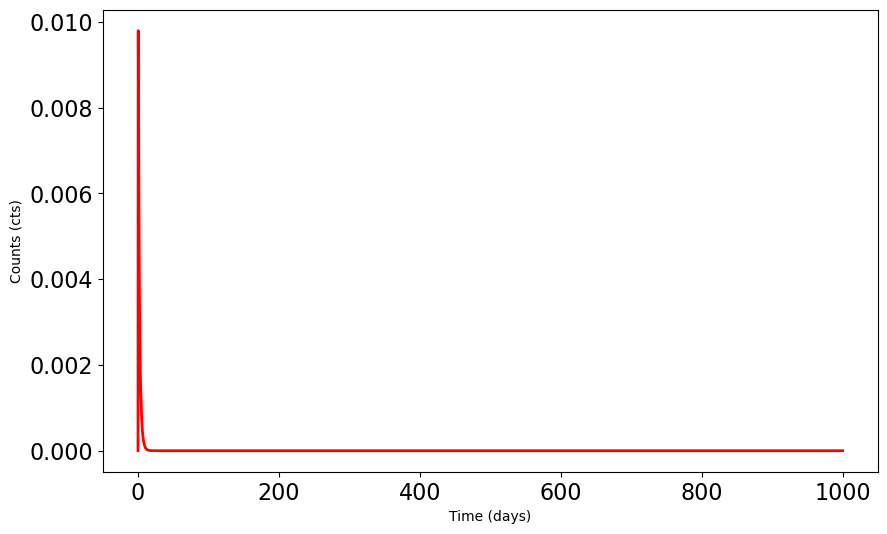

In [12]:
#plot of PSD based light curve
fig, ax = plt.subplots(1,1,figsize=(10,6))
ax.plot(times, psi_norm, lw=2, color='red')
#ax.set_xlim(-10,100)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Counts (cts)")
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
plt.show()

In [13]:
print(len(times))
print(len(time))



48000
48000


## cropping so that both lightcurves are using the same time array

In [14]:
signal_DISK = np.convolve(flux, psi_norm, mode='full')

#start_index2 = int((len(signal_DISK) - len(flux)) / 2)
#end_index2 = start_index2 + len(flux)
#signal_DISK = signal_DISK[start_index2:end_index2]

zero_idx = np.argmin(np.abs(times))
signal_DISK = signal_DISK[zero_idx:zero_idx + len(flux)]

# ---- CROP EDGE EFFECTS ----
# Estimate width of transfer function (in days)
tf_width = np.max(times[psi_norm > 0.01 * np.max(psi_norm)])

# Create mask to remove initial edge-affected region
mask = time > tf_width

# Apply mask to BOTH light curves
time_cut = time[mask]
flux_cut = flux[mask]
signal_cut = signal_DISK[mask]

#signal_DISK = signal_DISK[:len(time)]
lc_DISK = Lightcurve(time_cut, signal_cut)
lc = Lightcurve(time_cut, flux_cut)

c:\Users\Annie.LAPTOP-NJ5KV9M1\miniconda3\envs\agn\lib\site-packages\stingray\lightcurve.py:329: UserWarning: On Windows, the size of an integer is 32 bits. To avoid integer overflow, I'm converting the input array to float
  warnings.warn(


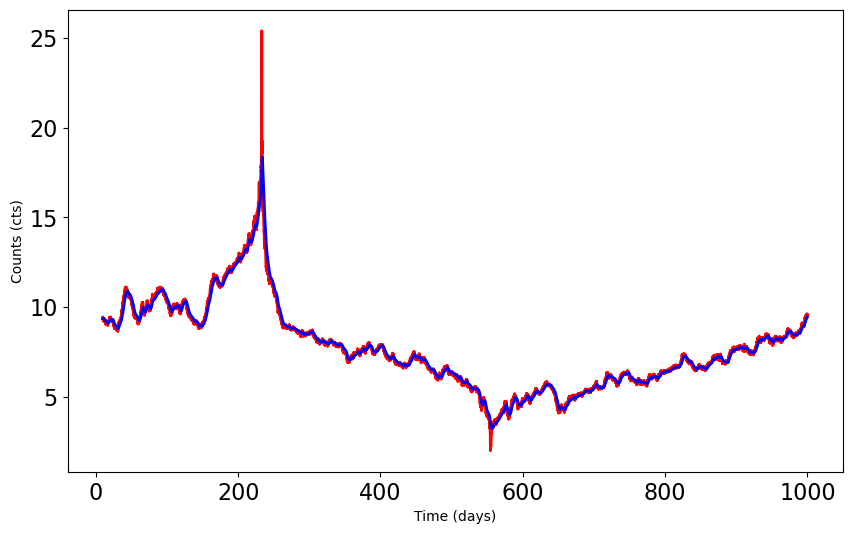

In [15]:
#plot of PSD based light curve
fig, ax = plt.subplots(1,1,figsize=(10,6))
ax.plot(lc.time, lc.counts, lw=2, color='red')
ax.plot(lc_DISK.time, lc_DISK.counts, lw=2, color='blue')
ax.set_xlabel("Time (days)")
ax.set_ylabel("Counts (cts)")
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
plt.show()

In [16]:
expected_index = len(combi_psi_1) // 2
print("Expected index of the peak:", expected_index)    

Expected index of the peak: 24000


In [17]:
np.argmax(combi_psi_1)


15

In [18]:
print(lc.time)
print(lc_DISK.time)

[  9.72916667   9.75         9.77083333 ... 999.9375     999.95833333
 999.97916667]
[  9.72916667   9.75         9.77083333 ... 999.9375     999.95833333
 999.97916667]


finding the centroid of the cross correlation function manually 

In [19]:
from stingray.crosscorrelation import CrossCorrelation

cc = CrossCorrelation(lc, lc_DISK)

lags = cc.time_lags
ccf  = cc.corr

mask = ccf > 0.8 * np.max(ccf)

tau_cent = np.sum(
    lags[mask] * ccf[mask]
) / np.sum(ccf[mask])

print("Centroid of the CCF:", tau_cent)

Centroid of the CCF: -1.8261484182185652


In [20]:
mean_lag = np.sum(times * combi_psi_1) / np.sum(combi_psi_1)
print("Mean lag from the disk response function:", mean_lag)

Mean lag from the disk response function: 2.0460921795204796


## frequency resolved lags 


In [21]:
import shutil

# Replace '/path/to/work_directory' with your actual work directory

src = r'C:\Users\Annie.LAPTOP-NJ5KV9M1\AGN_mapping\CPython\PYCCF.py'
dst = r'PYCCF.py'
dst2 = r'xcorspc.pyx'

shutil.copy(src, dst)
shutil.copy(src, dst2)


'xcorspc.pyx'

In [22]:
#average cross spectrum 
avg_cs_Disk = AveragedCrossspectrum.from_lightcurve(lc_DISK, lc, 150.)
#logarithmically rebin 
log_rb_cs_Disk = avg_cs_Disk.rebin_log(f=1.2)

6it [00:00, 641.45it/s]
c:\Users\Annie.LAPTOP-NJ5KV9M1\miniconda3\envs\agn\lib\site-packages\stingray\fourier.py:1134: UserWarning: n_ave is below 30. Please note that the error bars on the quantities derived from the cross spectrum are only reliable for a large number of averaged powers.
  warnings.warn(
c:\Users\Annie.LAPTOP-NJ5KV9M1\miniconda3\envs\agn\lib\site-packages\stingray\fourier.py:1161: RuntimeWarning: invalid value encountered in sqrt
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))


In [23]:
freq_lags_Disk, freq_lags_err_Disk = log_rb_cs_Disk.time_lag()
freq_plags_Disk, freq_plags_err_Disk = log_rb_cs_Disk.phase_lag()

c:\Users\Annie.LAPTOP-NJ5KV9M1\miniconda3\envs\agn\lib\site-packages\stingray\fourier.py:1134: UserWarning: n_ave is below 30. Please note that the error bars on the quantities derived from the cross spectrum are only reliable for a large number of averaged powers.
  warnings.warn(
c:\Users\Annie.LAPTOP-NJ5KV9M1\miniconda3\envs\agn\lib\site-packages\stingray\fourier.py:1161: RuntimeWarning: invalid value encountered in sqrt
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))


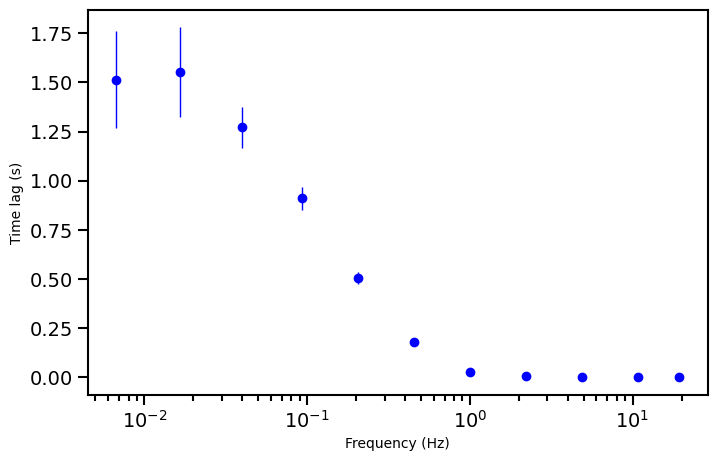

In [29]:
fig, ax = plt.subplots(1,1,figsize=(8,5))
#ax.hlines(0, log_rb_cs_Disk.freq[0], log_rb_cs_Disk.freq[-1], color='black', linestyle='dashed', lw=2)
ax.errorbar(log_rb_cs_Disk.freq, freq_lags_Disk, yerr=freq_lags_err_Disk,fmt="o", lw=1, color='blue')
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Time lag (s)")
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(which='major', width=1.5, length=7)
ax.tick_params(which='minor', width=1.5, length=4)
for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(1.5)
plt.semilogx()


plt.show()

print(log_rb_cs_Disk.freq)

In [34]:
np.set_printoptions(threshold=np.inf)
print(freq_lags_Disk)

[ 1.51442102e+00  1.55313688e+00  1.27122473e+00  9.10834659e-01
  5.04908033e-01  1.82759697e-01  2.87180429e-02  7.52622011e-03
  5.48355021e-04  3.29343250e-06 -1.97913489e-06]


##testing shakura-sunyaev wavelength lag dependancy 